# T-Test

### Independent t-test

In [1]:
import pandas as pd

df = pd.read_csv("customer_data.csv")
df.head()

,Age,Income,Satisfaction_Score,Wait_Time_Minutes,Purchase_Count,Gender,Education_Level
0,56,81832,1,8.66,3,Female,High School
1,69,65486,7,10.87,8,Other,Bachelor
2,46,27209,8,1.00,8,Female,High School
3,32,42736,3,10.56,5,Female,Master
4,60,69003,6,3.74,8,Female,Master


In [2]:
df.groupby("Gender")["Income"].mean()

Gender
Female    48361.500000
Male      50813.025862
Other     49127.947368
Name: Income, dtype: float64

In [4]:
male_salary = df[df["Gender"] == "Male"]["Income"]
female_salary = df[df["Gender"] == "Female"]["Income"]

print(male_salary)
print(female_salary)

6      56657
7      61619
16     43399
19     28462
21     50153
       ...  
494    52801
496    40827
497    28900
498    36151
499    29724
Name: Income, Length: 232, dtype: int64
0      81832
2      27209
3      42736
4      69003
5      39384
       ...  
484    53840
485    64740
487    65215
490    40627
495    38669
Name: Income, Length: 230, dtype: int64


In [5]:
from scipy.stats import ttest_ind

stat, p = ttest_ind(male_salary, female_salary, equal_var=False)
print("Stat:", stat)
print("p:",p)

Stat: 1.7718047680435454
p: 0.07708911413248488


In [6]:
df=pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
survived = df[df["Survived"]==1]["Age"].dropna()
non_survived = df[df["Survived"]==0]["Age"].dropna()

stat, p = ttest_ind(survived, non_survived, equal_var=False)
print("Stat:",stat)
print("p:",p)

Stat: -2.0460301043939704
p: 0.04118965162586637


### Paired t-test

In [16]:
from scipy.stats import ttest_rel

model_A = [0.82, 0.80, 0.83, 0.85, 0.81, 0.79, 0.84, 0.82, 0.83, 0.81]
model_B = [0.84, 0.85, 0.86, 0.87, 0.83, 0.82, 0.88, 0.86, 0.87, 0.84]

stat, p = ttest_rel(model_A, model_B)
print("stat", stat)
print("p", p)

stat -9.7979589711327
p 4.23973888625987e-06


In [28]:
from scipy.stats import t
import numpy as np

model_A = [0.82, 0.80, 0.83, 0.85, 0.81, 0.79, 0.84, 0.82, 0.83, 0.81]

mean = np.mean(model_A)
std = np.std(model_A)
n = len(model_A)

se = std/np.sqrt(n)

t_value = t.ppf(0.975, df=n-1)

lower = mean - t_value*se
upper = mean + t_value*se

print("Lower:", lower)
print("Upper:",upper)

Lower: 0.8076096549331353
Upper: 0.8323903450668646


In [31]:
Model_B= [0.84, 0.85, 0.86, 0.87, 0.83, 0.82, 0.88, 0.86, 0.87, 0.84]

mean = np.mean(Model_B)
std = np.std(Model_B)
n = len(Model_B)

se = std/np.sqrt(n)
t_value = t.ppf(0.975,df=n-1)

lower = mean - t_value*se
upper = mean + t_value*se

print("Lower:", lower)
print("Upper:", upper)

Lower: 0.8388872913179201
Upper: 0.8651127086820799


# Chi-square test

### Chi-square Independent test

In [32]:
import pandas as pd
import numpy as np

df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [33]:
pd.crosstab(df["Sex"],df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [35]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Sex"],df["Survived"])
chi2, p, dof, expected = chi2_contingency(table)
print("P:",p)

P: 1.1973570627755645e-58


In [36]:
df = pd.read_csv("customer_data.csv")
df.head()

,Age,Income,Satisfaction_Score,Wait_Time_Minutes,Purchase_Count,Gender,Education_Level
0,56,81832,1,8.66,3,Female,High School
1,69,65486,7,10.87,8,Other,Bachelor
2,46,27209,8,1.00,8,Female,High School
3,32,42736,3,10.56,5,Female,Master
4,60,69003,6,3.74,8,Female,Master


In [40]:
table = pd.crosstab(df["Satisfaction_Score"], df["Gender"])
print(table)

Gender              Female  Male  Other
Satisfaction_Score                     
1                       18    30      2
2                       22    31      6
3                       22    24      7
4                       27    15      1
5                       22    18      3
6                       26    19      3
7                       22    21      3
8                       17    31      7
9                       32    18      3
10                      22    25      3


In [41]:
from scipy.stats import chi2_contingency

chi2, p, df, expected = chi2_contingency(table)
print("p:",p)

p: 0.09518025621636061


# Anova

### One-way anova

In [46]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway

df = pd.read_csv("one-way-anova.csv")
df.head()

,Student,method,Score
0,1,A,78
1,2,A,82
2,3,A,85
3,4,A,80
4,5,A,79


In [49]:
grp_A = df[df["method"]=="A"]["Score"].dropna()
grp_B = df[df["method"]=="B"]["Score"].dropna()
grp_C = df[df["method"]=="C"]["Score"].dropna()

stats, p = f_oneway(grp_A, grp_B, grp_C)
print("p:",p)

p: 5.2956833130939864e-08


In [55]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df["Score"],
    groups=df["method"],
    alpha=0.05
)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     A      B      7.0 0.0007    3.193   10.807   True
     A      C  -9.3333    0.0 -13.1403  -5.5263   True
     B      C -16.3333    0.0 -20.1403 -12.5263   True
------------------------------------------------------


# Data set questions practise

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("customer_satisfaction_sample.csv")
df.head()

,CustomerID,SatisfactionScore,DeliveryTimeDays,PurchaseAmount,Gender
0,1,2,5.95,1435.55,Male
1,2,4,4.76,1598.51,Female
2,3,4,6.27,2696.80,Male
3,4,4,8.52,2553.07,Female
4,5,4,4.61,1983.35,Female


In [3]:
df[["SatisfactionScore", "DeliveryTimeDays"]].describe()

,SatisfactionScore,DeliveryTimeDays
count,300.000000,300.000000
mean,3.300000,5.302533
std,1.263059,1.990232
min,1.000000,1.610000
25%,2.000000,3.935000
50%,3.000000,5.105000
75%,4.000000,6.222500
max,5.000000,19.260000


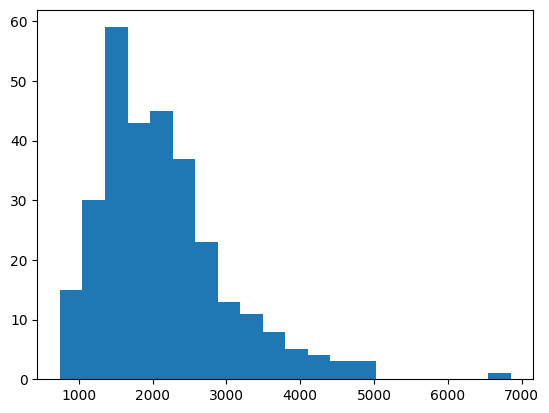

In [4]:
plt.hist(df['PurchaseAmount'],bins=20)
plt.show()

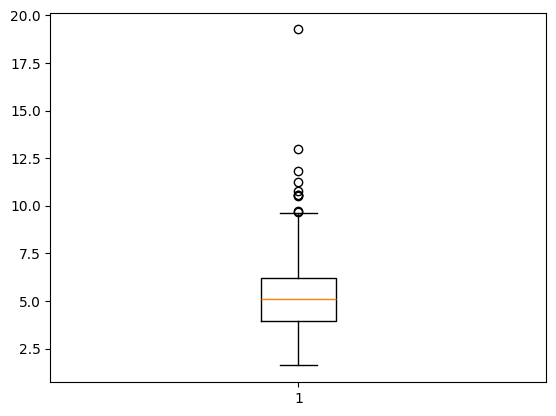

In [6]:
plt.boxplot(df["DeliveryTimeDays"])
plt.show()

In [8]:
print(df["PurchaseAmount"].skew())
print(df["PurchaseAmount"].kurtosis())

1.3614334876097387
3.094011825322587


In [11]:
sample = df.sample(n=30,random_state=42)
sample["PurchaseAmount"].mean().round(2)

np.float64(1932.79)

In [15]:
from scipy.stats import norm
mean = df["PurchaseAmount"].mean()
std = df["PurchaseAmount"].std()
n = 30

se = std/np.sqrt(n)
prob = norm.sf(1500, mean, se).round(2)
print(prob)

1.0


In [18]:
from scipy.stats import ttest_ind

male = df[df["Gender"]=="Male"]["PurchaseAmount"].dropna()
female = df[df["Gender"]=="Female"]["PurchaseAmount"].dropna()

stat, p = ttest_ind(male, female)
print("p:",p)

p: 0.7252496535047339


In [20]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Gender"], df["SatisfactionScore"])
ch2, p, dof, expected = chi2_contingency(table)
print("p:",p)

p: 0.4569371137118481


# Titanic practise

In [21]:
import pandas as pd
import numpy as np

df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [22]:
from scipy.stats import ttest_ind

survived = df[df["Survived"]==1]["Age"].dropna()
non_survived = df[df["Survived"]==0]["Age"].dropna()

stat, p = ttest_ind(survived, non_survived)
print("p:",p)

p: 0.039124654013482474


In [23]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Sex"], df["Survived"])
chi2, p, a, expected = chi2_contingency(table)
print("p:",p)

p: 1.1973570627755645e-58


##### a) Write Python code to compute a 95% confidence interval for the mean Fare of survivors.

In [25]:
from scipy.stats import t

fare_survived = df[df["Survived"]==1]["Fare"].dropna()
mean = fare_survived.mean()
std = fare_survived.std()
n = len(fare_survived)
se = std/np.sqrt(n)

t_value = t.ppf(0.975, df=n-1)
lower = mean - t_value*se
upper = mean + t_value*se

print("Lower: ",lower)
print("Upper:",upper)

Lower:  41.31213680463354
Upper: 55.47867840004483


### Z-TEST FOR PROPORTION

In [26]:
from statsmodels.stats.proportion import proportions_ztest

success = 110
n = 200
p0 = 0.6

stat, p = proportions_ztest(success, n, value=p0)
print(p)

0.1552184896846846


### CI FOR PROPORTION

In [28]:
from statsmodels.stats.proportion import proportion_confint

lower, upper = proportion_confint(success,n,0.05)
print(lower,upper)

0.4810521552867026 0.6189478447132976


# IMP Data set Practise

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df=sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


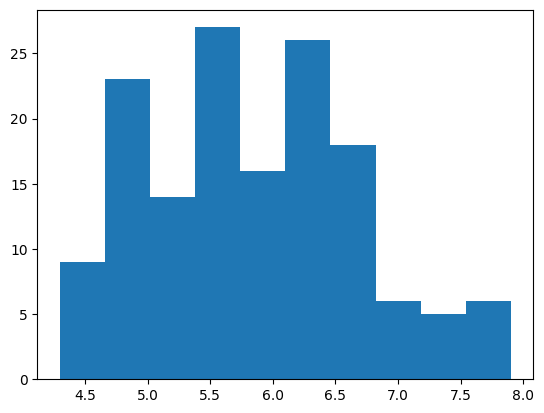

In [34]:
plt.hist(df["sepal_length"])
plt.show()

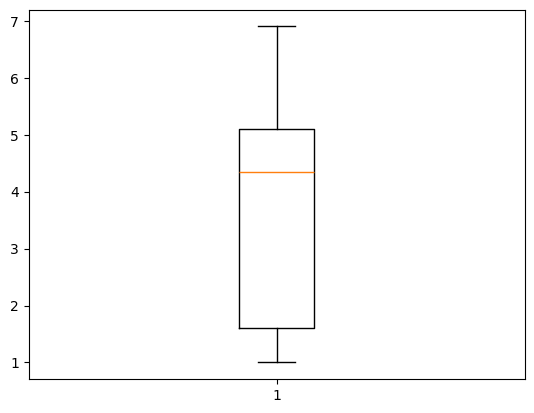

In [36]:
plt.boxplot(df["petal_length"])
plt.show()

In [39]:
from scipy.stats import f_oneway

print(df["species"].unique())

grp1 = df[df["species"]=="setosa"]["petal_length"].dropna()
grp2 = df[df["species"]=="versicolor"]["petal_length"].dropna()
grp3 = df[df["species"]=="virginica"]["petal_length"].dropna()

stat, p = f_oneway(grp1, grp2, grp3)
print("p:",p)

<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str
p: 2.8567766109624403e-91


# FINAL QUESTION -PRACTICE

In [42]:
import seaborn as sns
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df["fare"].skew()

np.float64(4.787316519674893)

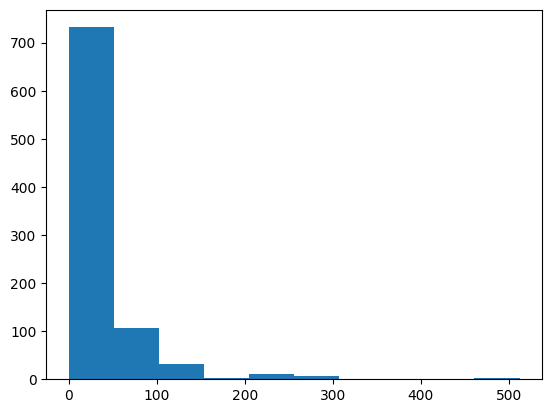

In [45]:
import matplotlib.pyplot as plt
plt.hist(df["fare"])
plt.show()

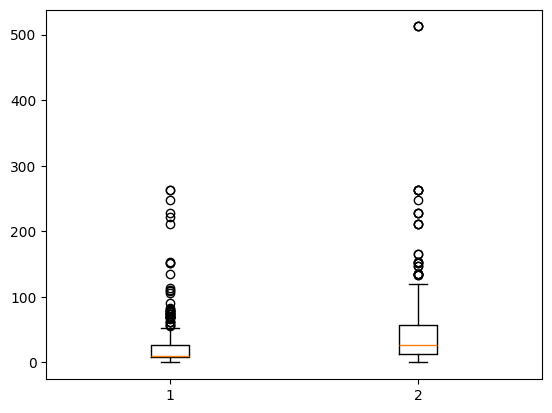

In [49]:
grp1 = df[df["survived"]==0]["fare"]
grp2 = df[df["survived"]==1]["fare"]
plt.boxplot([grp1, grp2])
plt.show()

In [51]:
sample = df["fare"].dropna().sample(n=40, random_state=42)
print(sample)

709    15.2458
439    10.5000
840     7.9250
720    33.0000
39     11.2417
290    78.8500
300     7.7500
333    18.0000
208     7.7500
136    26.2833
137    53.1000
696     8.0500
485    25.4667
244     7.2250
344    13.0000
853    39.4000
621    52.5542
653     7.8292
886    13.0000
110    52.0000
294     7.8958
447    26.5500
192     7.8542
682     9.2250
538    14.5000
819    27.9000
30     27.7208
673    13.0000
63     27.9000
396     7.8542
877     7.8958
141     7.7500
793    30.6958
235     7.5500
204     8.0500
620    14.4542
23     35.5000
198     7.7500
842    31.0000
739     7.8958
Name: fare, dtype: float64


In [52]:
from scipy.stats import norm
import numpy as np

mean = sample.mean()
std = sample.std()
n = len(sample)
se = std/np.sqrt(n)

prob = norm.sf(50, mean, se)
print(prob)

7.368499518193905e-30


In [53]:
from scipy.stats import t

fare_survived = df[df["survived"]==1]["fare"].dropna()
mean = fare_survived.mean()
std = fare_survived.std()
n = len("fare_survived")
se = std/np.sqrt(n)
t_value = t.ppf(0.975, df=n-1)

lower = mean - t_value*se
upper = mean + t_value*se

print(lower)
print(upper)

8.151244412955059
88.63957079172332


In [54]:
from scipy.stats import ttest_ind

fare_survived = df[df["survived"]==1]["fare"].dropna()
fare_non = df[df["survived"]==0]["fare"].dropna()

stat, p = ttest_ind(fare_survived, fare_non)
print("p:",p)

p: 6.1201893419242075e-15


In [56]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["survived"], df["sex"])
chi2, p, dof, expected = chi2_contingency(table)
print("p:",p)

p: 1.1973570627755645e-58
